# Optimering af batterilagerdispatch til energiarbitrage og spidslastreduktion

## Resumé

Et netforbundet erhvervssted driver et 2 MW / 8 MWh lithium-ion-batteri sammen med en målt elektrisk last. Stedet afregnes på to måder: en time-baseret day-ahead **energipris** ($/MWh) og et månedligt **effektgebyr** på dets enkelt højeste netimportinterval ($/MW). Aktivforvalteren skal beslutte, time for time, hvornår batteriet skal oplades (køb af billig energi og øget netudtræk) og hvornår det skal aflades (modregning af dyr energi og reduceret netudtræk). To værdistrømme konkurrerer: **energiarbitrage** (køb billigt om natten, aflad ved aftenspidsen) og **spidslastreduktion** (loft over det afregnede netmaksimum). Opladning er ikke gratis — round-trip-virkningsgraden betyder, at cirka 10 % af den lagrede energi går tabt — så planen er en ægte optimering, ikke en heuristik.

Denne notebook opbygger beslutningen fra ende til anden. Den syntetiserer først en realistisk 24-timers day-ahead-priskurve (med morgen- og aftenspidser plus en nattelav) og en korreleret lastprofil for stedet, og profilerer derefter begge med **PROC MEANS** og et robust **PROC UNIVARIATE**-prisbånd på 2.5/97.5-percentilen. Kernen er et lineært program i **PROC OPTMODEL**: beslutningsvariabler for time-baseret opladning, afladning og ladetilstand, plus en afregnet-spids-variabel, underlagt en kumulativ ladetilstandsbalance (med separat opladnings-/afladningsvirkningsgrad), effekt- og kapacitetsgrænser samt en spidsdefinitionsbetingelse. Målfunktionen maksimerer arbitragemargin fratrukket effektgebyret. **PROC SQL** kvantificerer derefter omkostningen ved basislinje kontra optimeret, og tre **PROC SGPLOT**-paneler visualiserer opladnings-/afladningsplanen mod prisen, ladetilstandsforløbet og den udjævnede netimportprofil.

**Resultat på den syntetiske dag:** optimeringsværktøjet fylder batteriet i de billigste nattetimer, aflader ind i både morgen- og aftenprisspidserne, genoplader gennem middagsprisdalen og — afgørende — holder sin opladningseffekt tilbage, så det aldrig skaber en ny netspids. De daglige energiomkostninger falder fra **\$2,903.78 til \$2,528.43** — **\$375.34 (12.9%) i arbitragebesparelser** — mens det afregnede netmaksimum falder fra **3.59 MW til 3.43 MW** (cirka **0.16 MW**), hvilket er yderligere **\$18.98** værd ved det antagne effektgebyr for dagens andel. Den samme model skalerer til længere horisonter, flere prisscenarier eller nedbrydningsbevidst cykling ved blot at udvide indeksmængden og betingelserne.

## Datakilder

Alle data er **syntetiske** og genereres inline i den første kodecelle med `CALL STREAMINIT(20260605)` for reproducerbarhed. Ingen eksterne filer eller netværksadgang. Ét datasæt, `price_load`, med 24 timerækker, der repræsenterer en enkelt driftsdag.

| Variabel | Type | Enheder | Beskrivelse |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Time på driftsdagen (horisontindeks) |
| `price` | num | $/MWh | Day-ahead-energipris: nattelav, morgen- + aftenspidser, med Gaussisk støj (gulv ved $5) |
| `load` | num | MW | Elektrisk efterspørgsel på stedet, korreleret med daglig aktivitet (gulv ved 0.3 MW) |
| `day_type` | char | — | Tarifvinduesflag: `PeakTOU` (timerne 17–21) vs `OffPeak`, brugt til opsummeringen af pris-spread mellem spids/uden-for-spids |

Batteriparametrene er faste modelkonstanter inde i PROC OPTMODEL: 8 MWh brugbar kapacitet, 2 MW maks. opladnings-/afladningseffekt, 0.95 opladnings- og 0.95 afladningsvirkningsgrad (~90 % round trip), start-ladetilstand 0 MWh, og et \$120/MW effektgebyr anvendt på dagens afregnede netspids (den dagligt amortiserede andel af et månedligt effektgebyr).

# Optimering af batterilagerdispatch
## Energiarbitrage og spidslastreduktion for et netforbundet sted

Et erhvervssted driver et **2 MW / 8 MWh-batteri** bag sin måler. Dets elregning har to dele: en time-baseret **energipris** ($/MWh) og et månedligt **effektgebyr** på det enkelt højeste netimportinterval ($/MW). Operatøren ønsker en time-baseret opladnings-/afladningsplan, der fanger to værdistrømme på én gang:

- **Arbitrage** — lagr billig natteenergi, frigiv den i dyre spidstimer.
- **Spidslastreduktion** — aflad under efterspørgselsspidsen for at sænke det afregnede netmaksimum.

Fordi round-trip-virkningsgraden mister ~10 % af den lagrede energi, er afvejningen ikke-triviel og berettiger en ægte optimering. Vi formulerer den som et lineært program i **PROC OPTMODEL** og kvantificerer og visualiserer derefter resultatet.

> Alle data nedenfor er syntetiske og genereret inline — denne notebook er fuldt selvstændig og kører på få sekunder.

## 1. Generér en syntetisk day-ahead pris- og lastprofil

Vi opbygger én driftsdag (24 timerækker). Priskurven har en nattelav og morgen- + aftenspidser; lasten på stedet er korreleret med daglig aktivitet. Et fast seed holder kørslen reproducerbar. Vi mærker også det lovbestemte time-of-use-spidsvindue, så vi kan opsummere pris-spreadet mellem spids/uden-for-spids senere.

In [1]:
data price_load;
    CALL streaminit(20260605);
    LÆNGDE day_type $12;
    GØR hour = 0 TIL 23;
        /* Diurnal energipris ($/MWh): morgen- + aftenspidser */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        HVIS price < 5 SÅ price = 5;

        /* Stedets last (MW): nattelav, aftenrampe */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        HVIS LOAD < 0.3 SÅ LOAD = 0.3;

        HVIS hour >= 17 AND hour <= 21 SÅ day_type = 'Spidslast';
        ELLERS day_type = 'UdenSpids';
        UDDATA;
    SLUT;
    FJERN BASE;
KØR;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilér pris- og lastfordelingerne

Før optimeringen sanity-checker vi inputtene. Spreadet mellem de billigste og dyreste timer er, hvad arbitragen tjener penge på, og maksimallasten forankrer muligheden for spidslastreduktion.

In [2]:
TITEL "Pris- og lastfordeling";
PROCEDURE GENNEMSNIT data=price_load n mean std MIN MAX maxdec=2;
    VARIABEL price LOAD;
    MÆRKAT price="Pris ($/MWh)" LOAD="Last (MW)";
KØR;
TITEL;

                                                 Pris- og lastfordeling                                                 

                                                  The MEANS Procedure

 Variable  Label               N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------
 price     Pris ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Last (MW)          24        2.47        0.48        1.71        3.59
 -------------------------------------------------------------------------------




NOTE: Option TITLE changed to Pris- og lastfordeling.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Pris-spread mellem spids og uden for spids

Gruppering efter time-of-use-flaget viser, hvor meget rigere spidstimerne er end basislinjen uden for spids — det strukturelle signal, batteriet udnytter.

In [3]:
TITEL "Pris-spread mellem spids og uden for spids";
PROCEDURE GENNEMSNIT data=price_load mean MIN MAX maxdec=2;
    KLASSE day_type;
    VARIABEL price;
    MÆRKAT price="Pris ($/MWh)" day_type="Tarifvindue";
KØR;
TITEL;

                                       Pris-spread mellem spids og uden for spids                                       

                                                  The MEANS Procedure

                                        Analysis Variable : price Pris ($/MWh)

                                                 N
                                Tarifvindue    Obs       Mean      Minimum      Maximum
                                -------------------------------------------------------
                                Spidslast        5      68.45        54.88        79.27
                                UdenSpids       19      40.46        18.57        54.89
                                -------------------------------------------------------




NOTE: Option TITLE changed to Pris-spread mellem spids og uden for spids.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Robust prisbånd (2.5 / 97.5 percentiler)

Vi karakteriserer prishalerne med et 2.5 / 97.5-percentilbånd. **PROC UNIVARIATE** med `PCTLPTS=` beregner vilkårlige percentiler rent, hvilket er det rette værktøj til fraktionelle percentiler.

In [4]:
PROCEDURE UNIVARIATE data=price_load NOPRINT;
    VARIABEL price;
    UDDATA out=price_band pctlpts=2.5 97.5 pctlpre=p_;
KØR;

TITEL "Robust prisbånd (2.5 / 97.5 percentiler)";
PROCEDURE UDSKRIV data=price_band noobs label;
    MÆRKAT p_2_5="Pris P2.5 ($/MWh)" p_97_5="Pris P97.5 ($/MWh)";
KØR;
TITEL;

                                        Robust prisbånd (2.5 / 97.5 percentiler)                                        


Pris P2.5 ($/MWh)  Pris P97.5 ($/MWh)
-----------------  ------------------
            18.57               79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: Option TITLE changed to Robust prisbånd (2.5 / 97.5 percentiler).
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. Dispatch-optimeringen (lineært program)

Vi indlæser den time-baserede pris og last i PROC OPTMODEL og deklarerer:

- `chg[h]`, `dis[h]` — time-baseret opladnings-/afladningseffekt (MW), begrænset af 2 MW-inverterens mærkeeffekt.
- `soc[h]` — ladetilstand (MWh), begrænset af den brugbare kapacitet på 8 MWh.
- `peak` — det afregnede netmaksimum (MW).

**Betingelser.** `soc_balance` akkumulerer nettoenergi gennem hver time med separat opladnings-/afladningsvirkningsgrad (en løbende-sum-form af time-rekurrensen). `peak_def` tvinger `peak` til at dominere hver times netto-netimport, så minimering af den skærer i effektgebyret.

**Målfunktion.** Maksimér arbitragemargin — `price × (discharge − charge)` summeret over dagen — minus effektgebyret på den afregnede spids. Vi løser som et kontinuert LP.

In [5]:
PROCEDURE optmodel;
    SÆT HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ data price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Batteri: 8 MWh brugbar, 2 MW effekt, ~90% round-trip-virkningsgrad */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Effektgebyr anvendt på dagens afregnede netspids ($/MW).
       Erhvervseffektgebyrer er månedlige; 120 er marginalværdien af at
       skære dagens netmaksimum, når det månedlige gebyr amortiseres til
       dagen. Det er stort nok til, at optimeringsværktøjet holder
       opladningseffekt tilbage frem for at skabe en ny, højere spids. */
    num demand_chg = 120;

    /* Beslutningsvariabler (MW opladning / afladning, MWh ladetilstand) */
    VARIABEL chg{HOURS}  >= 0 <= p_max;
    VARIABEL dis{HOURS}  >= 0 <= p_max;
    VARIABEL soc{HOURS}  >= 0 <= capacity;
    VARIABEL peak        >= 0;   /* afregnet netspids (MW) for effektgebyr */

    /* Netto-netimport efter batteriaktion (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Kumulativ ladetilstand: energi ind minus energi ud gennem time h,
       med opladnings-/afladningsvirkningsgrad anvendt. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Spidslastreduktion: afregnet spids er den maksimale netimport på dagen */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maksimér energiarbitragemargin fratrukket spidseffektgebyret */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE data dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. Den optimale time-baserede plan

Den løste tabel viser opladning spredt over de billige natte- og middagstimer — modereret til cirka 1.0–1.7 MW, så den aldrig sætter en ny netspids — afladning koncentreret i morgen- og aftenprisspidserne, og ladetilstanden, der tegner en fornuftig fyld-og-frigiv-cyklus inden for 8 MWh-loftet. Kolonnen `grid_mw` holder et fladt loft på ~3.43 MW gennem hver opladningstime, signaturen af den bindende spidsbetingelse.

In [6]:
TITEL "Den optimale time-baserede plan";
PROCEDURE UDSKRIV data=dispatch noobs label;
    VARIABEL hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    MÆRKAT hour="Time" price="Pris ($/MWh)" LOAD="Last (MW)"
        charge_mw="Opladning (MW)" discharge_mw="Afladning (MW)"
        soc_mwh="Ladetilstand (MWh)" grid_mw="Netimport (MW)";
KØR;
TITEL;

                                            Den optimale time-baserede plan                                             


Time  Pris ($/MWh)  Last (MW)  Opladning (MW)  Afladning (MW)  Ladetilstand (MWh)  Netimport (MW)
----  ------------  ---------  --------------  --------------  ------------------  --------------
   0         29.73       1.99       1.4418421               0             1.36975       3.4318421
   1         28.03       2.16       1.2718421               0               2.578       3.4318421
   2         21.87          2       1.4318421               0             3.93825       3.4318421
   3         18.57       1.71       1.7218421               0               5.574       3.4318421
   4         27.62       2.13       1.3018421               0             6.81075       3.4318421
   5         36.12       2.18       1.2518421               0                   8       3.4318421
   6         50.37       2.32               0               0                   8            


NOTE: Option TITLE changed to Den optimale time-baserede plan.
NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. Nøgle-KPI'er: basislinje kontra optimeret

Vi sammenligner den gør-ingenting-basislinje (betal prisen for den rå last hver time) mod den optimerede netposition og rapporterer arbitragebesparelserne, reduktionen i afregnet spids og dollarværdien af den reduktion ved effektgebyret — de to løftestænger, der driver forretningscasen.

In [7]:
PROCEDURE SQL;
    CREATE TABLE kpi AS
    VÆLG
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

TITEL "Nøgle-KPI'er: basislinje kontra optimeret";
PROCEDURE UDSKRIV data=kpi noobs label;
    MÆRKAT base_energy_cost="Basisomkostning ($)"
        opt_energy_cost="Optimeret omkostning ($)"
        arbitrage_savings="Arbitragebesparelse ($)"
        base_peak_mw="Basisspids (MW)"
        opt_peak_mw="Optimeret spids (MW)"
        peak_reduction_mw="Spidsreduktion (MW)"
        demand_charge_savings="Effektgebyrbesparelse ($)";
KØR;
TITEL;

                                       Nøgle-KPI'er: basislinje kontra optimeret                                        


Basisomkostning ($)  Optimeret omkostning ($)  Arbitragebesparelse ($)  Basisspids (MW)  Optimeret spids (MW)  Spidsreduktion (MW)  Effektgebyrbesparelse ($)
-------------------  ------------------------  -----------------------  ---------------  --------------------  -------------------  -------------------------
          2903.7774           2528.4335145526           375.3438854474             3.59             3.4318421            0.1581579                  18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: Option TITLE changed to Nøgle-KPI'er: basislinje kontra optimeret.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Opladnings-/afladningsplan mod prisen

Opladning (blå nåle) og afladning (rød linje med markører) deler den venstre megawatt-akse; day-ahead-prisen (grøn stiplet) aflæses til højre. Opladning klynger sig i de billige natte- og middagstimer, mens afladning fyrer ind i morgen- og aftenprisspidserne — det visuelle bekræfter, at optimeringsværktøjet køber billigt og sælger dyrt.

                                         Opladnings-/afladningsplan mod prisen                                          




NOTE: Option TITLE changed to Opladnings-/afladningsplan mod prisen.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


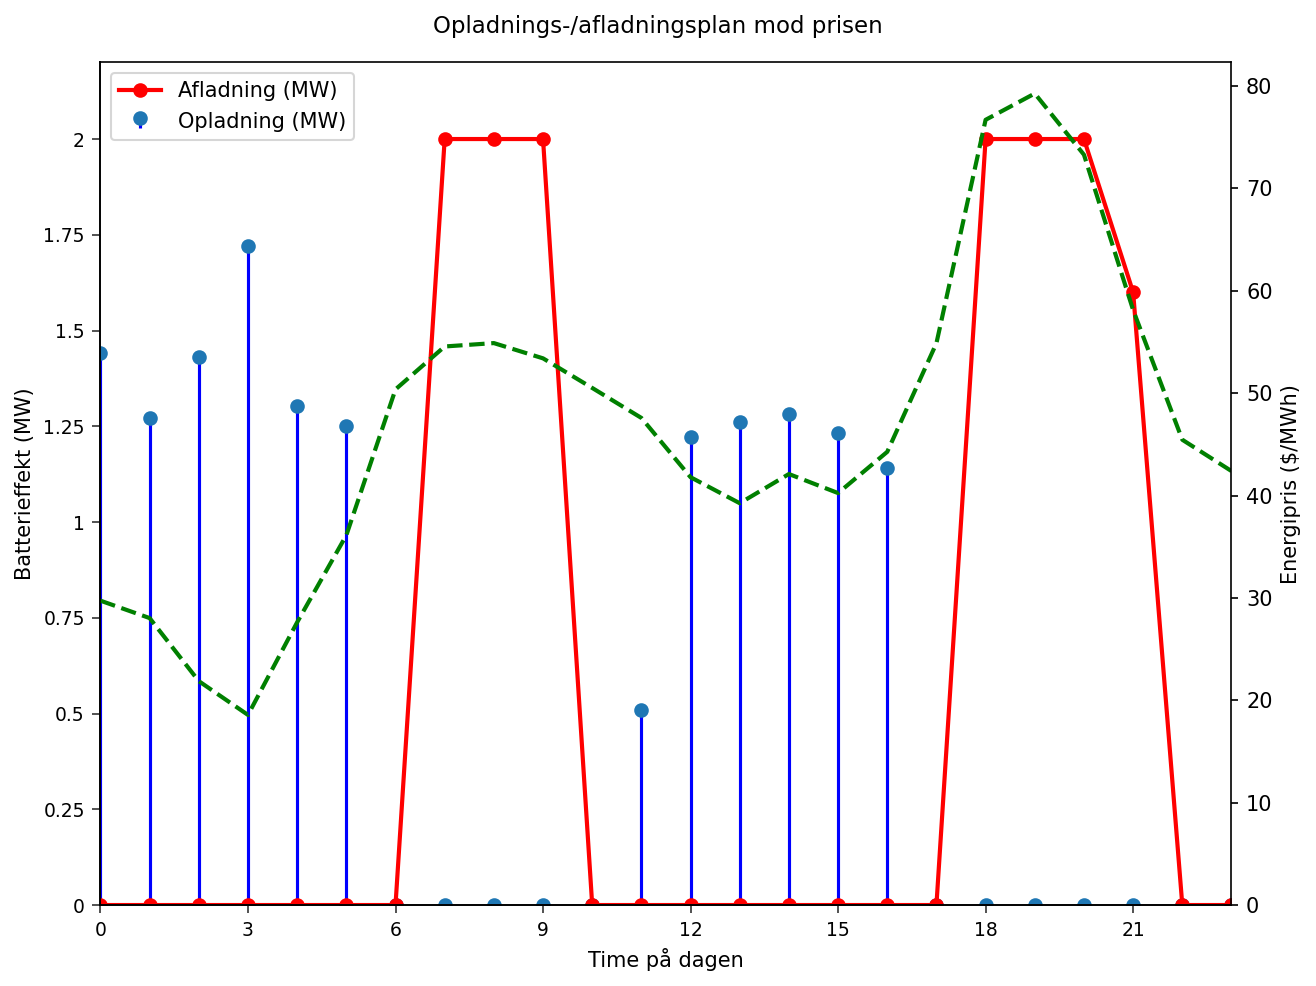

In [8]:
TITEL "Opladnings-/afladningsplan mod prisen";
PROCEDURE SGPLOT data=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Opladning (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Afladning (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Pris ($/MWh)";
    XAXIS MÆRKAT="Time på dagen" VALUES=(0 TIL 23 EFTER 3);
    YAXIS MÆRKAT="Batterieffekt (MW)" MIN=0 MAX=2.2;
    y2axis MÆRKAT="Energipris ($/MWh)" MIN=0;
KØR;
TITEL;

## 9. Ladetilstandsforløb

Den lagrede energi stiger, når batteriet fylder om natten, trækkes ned gennem hvert afladningsvindue og bryder aldrig loftet for brugbar kapacitet på 8 MWh (stiplet reference).

                                                  Ladetilstandsforløb                                                   




NOTE: Option TITLE changed to Ladetilstandsforløb.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


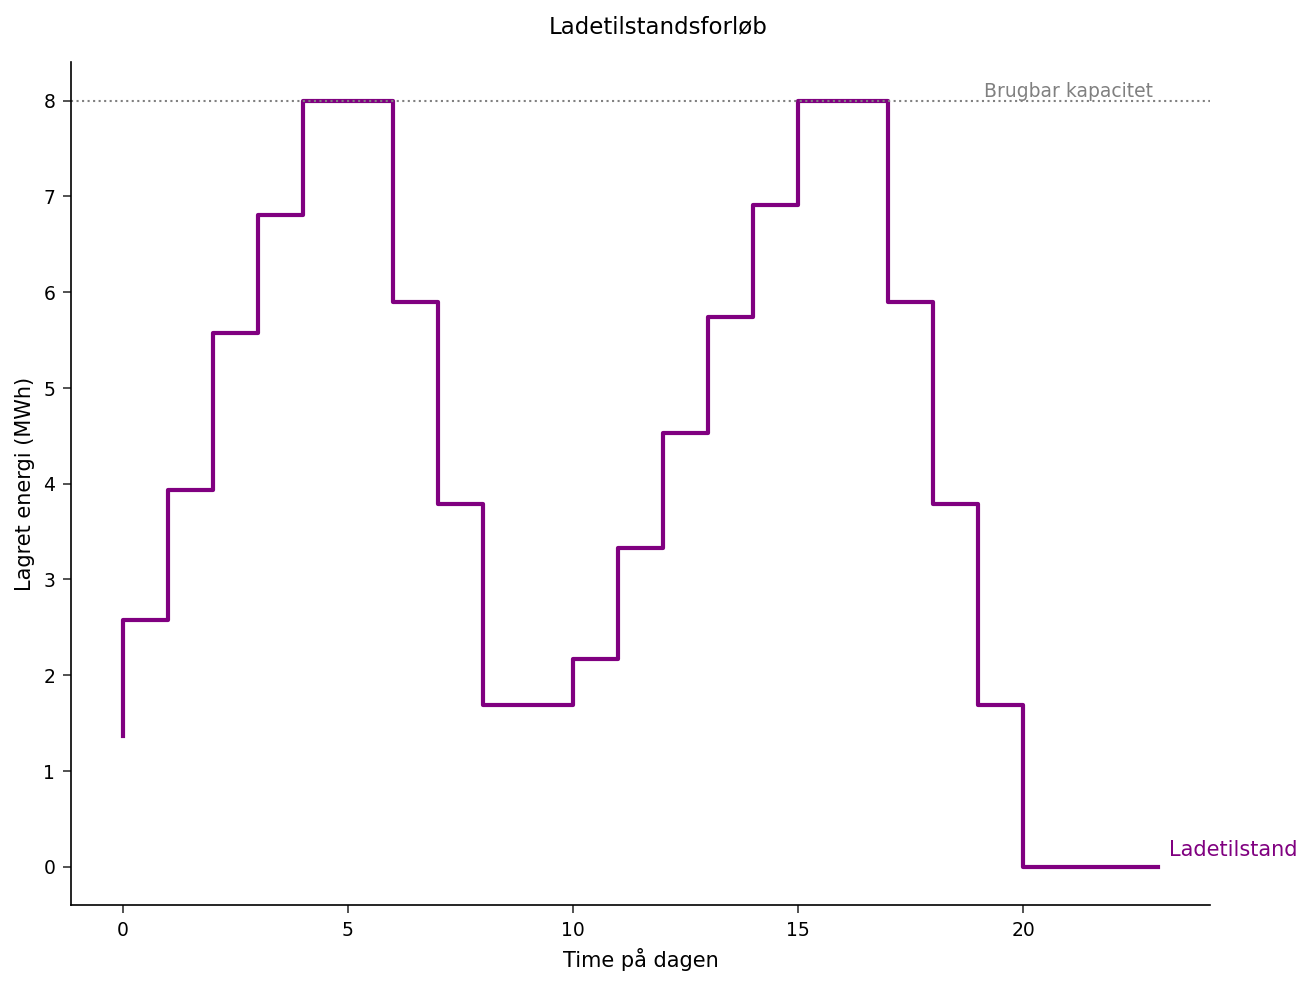

In [9]:
TITEL "Ladetilstandsforløb";
PROCEDURE SGPLOT data=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Ladetilstand";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        MÆRKAT="Brugbar kapacitet";
    XAXIS MÆRKAT="Time på dagen";
    YAXIS MÆRKAT="Lagret energi (MWh)";
KØR;
TITEL;

## 10. Netimport: før kontra efter dispatch

Den orange linje (netimport med batteriet) falder et godt stykke under den stiplede basislinjelast gennem aftenrampen (timerne 18–21) — den spidslastreducerende effekt, der sænker effektgebyret. I opladningsvinduerne om natten og midt på dagen stiger den, men optimeringsværktøjet sætter loft over den ved et fladt loft på ~3.43 MW, der forbliver *under* den oprindelige lastspids på 3.59 MW, så opladning køber billig energi uden at sætte et nyt afregnet maksimum.

                                          Netimport: før kontra efter dispatch                                          




NOTE: Option TITLE changed to Netimport: før kontra efter dispatch.
NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


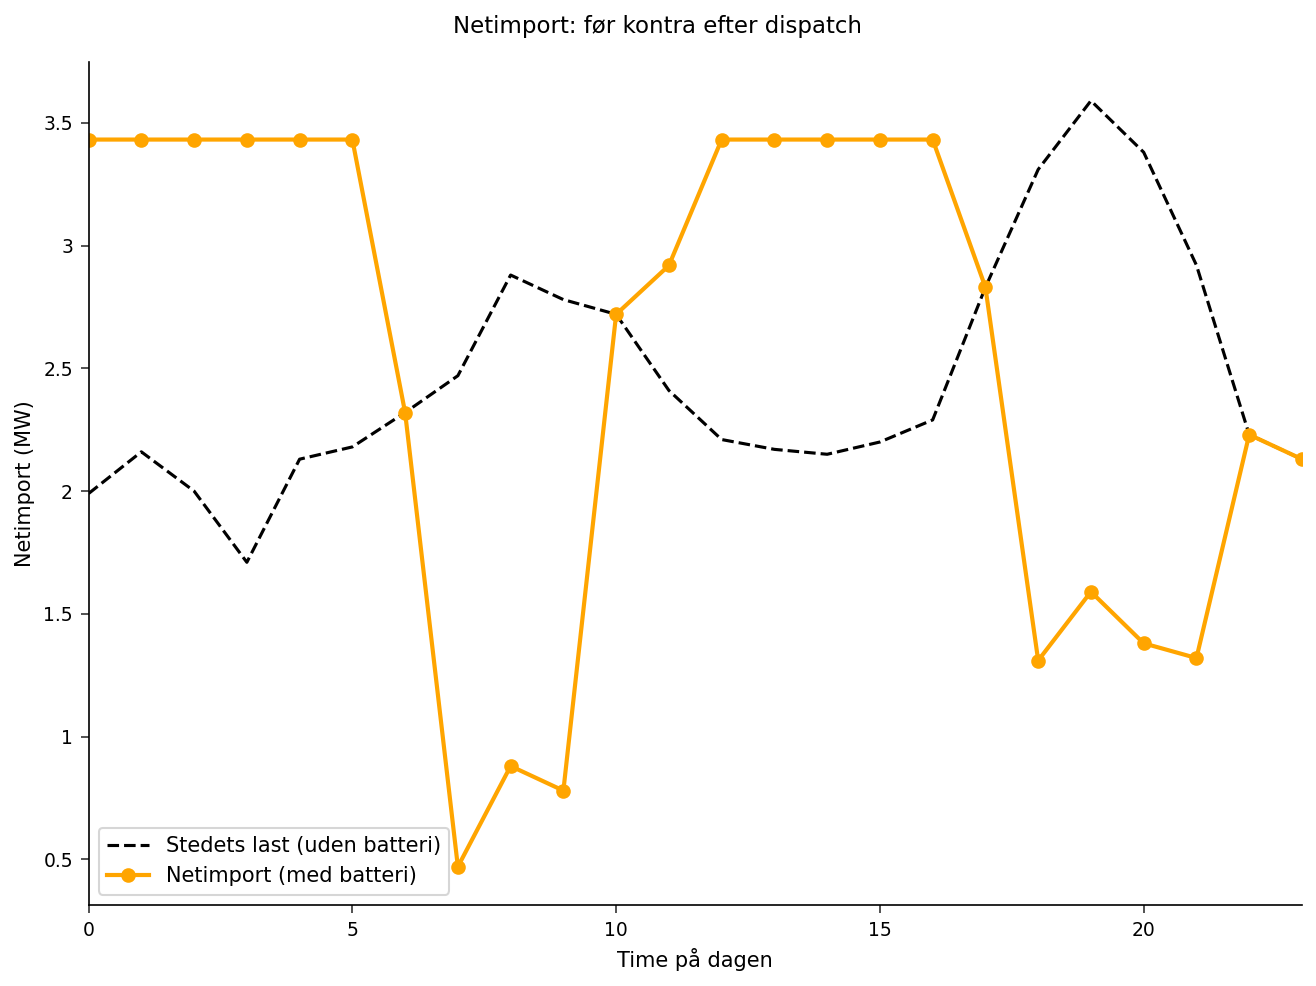

In [10]:
TITEL "Netimport: før kontra efter dispatch";
PROCEDURE SGPLOT data=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Stedets last (uden batteri)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Netimport (med batteri)";
    XAXIS MÆRKAT="Time på dagen";
    YAXIS MÆRKAT="Netimport (MW)";
KØR;
TITEL;

## Fortolkning og næste skridt

**Hvad modellen besluttede.** Selv med round-trip-virkningsgraden, der beskatter hver cyklus, fandt optimeringsværktøjet stadig klar værdi: det fyldte batteriet i de billigste nattetimer, aflades ind i morgenprisspidsen (timerne 7–9), genoplader gennem middagsprisdalen (timerne 11–16) og aflades igen ind i den rigeste aftenspids (timerne 18–21). Sigende nok opladede det kun med 1.0–1.7 MW frem for den fulde mærkeeffekt på 2 MW under nattefyldningen — holdt effekt tilbage, så det ekstra netudtræk aldrig skubbede importen over dagens lastspids. Ladetilstanden respekterede både kapaciteten på 8 MWh og effektgrænsen på 2 MW til enhver tid.

**Forretningscasen.** De daglige energiomkostninger faldt fra **\$2,903.78 til \$2,528.43** — **\$375.34 (12.9%)** i arbitragebesparelser — og det afregnede netmaksimum faldt fra **3.59 MW til 3.43 MW** (cirka **0.16 MW**), hvilket skærer yderligere **\$18.98** af effektgebyrlinjen. Årligt over driftsdage plus den tilbagevendende reduktion i effektgebyr er dette den slags margin, der underbygger en lagerinvestering.

**Hvorfor et LP er det rette værktøj.** Heuristikker ("oplad under medianprisen, aflad over") ignorerer virkningsgradstab, kapacitetskobling på tværs af timer og det faktum, at effektgebyret afhænger af et enkelt interval — de ville oplade med fuld effekt om natten og *hæve* den afregnede spids, hvilket ødelægger værdien af spidslastreduktion. PROC OPTMODEL fanger alle disse i én deklarativ model og returnerer den beviseligt optimale plan, som her bevidst modererer opladningsraten for at beskytte spidsen.

**Udvidelse af modellen.**

- **Længere horisonter / flere dage** — udvid indeksmængden `HOURS`; tilføj cyklusgrænser mellem dage.
- **Prisusikkerhed** — løs LP'et på tværs af flere prisscenarier og gennemsnitliggør beslutningen for første time (en rullende stokastisk politik).
- **Batterinedbrydning** — tilføj et gennemstrømningsstrafled eller en betingelse på kumulative cyklusser for at afveje arbitrage mod aktivets levetid.
- **Frekvensrespons / kapacitetsmarkeder** — indfør reserveret-headroom-betingelser, så batteriet kan stable indtægt fra hjælpetjenester oven på arbitrage.

Alle disse er trinvise ændringer af den samme OPTMODEL-blok — strukturen, der er etableret her, føres uændret igennem.